### High-level setup

In [2]:
#USE_COLAB = False     ## Set to False if running in a personal workstation
### First part, just change the scale 
### MI_ESTIMATOR = "DC"
## NDE_NET = "MAF"
FFD_SCALE = 3.0       ## Switch between 1.0/3.0/4.0/5.0

### Second part, fix FFD_SCALE = 3.0
### NDE_NET = "MAF", Change MI_ESTIMATOR
MI_ESTIMATOR = "DV"   ## Switch between JSD/DC/DV

DISCREPANCY = "JSD"   ## Do not change this option
USE_CUDA = False       ## Switch to True if running in Colab or Workstation with GPU

### Third part, fix FFD_SCALE = 3.0, fix MI_ESTIMATOR = "DC", change NDE_NET
NDE_NET = 'MAF'       ## Select between MAF and NDN

### Import modules

In [4]:
import os, sys, inspect, time
"""
solve the conflict between paths, and work dir
"""
CWD = os.getcwd()
PROJ_DIR = os.path.dirname(CWD)
sys.path.append(PROJ_DIR)
#os.chdir('../')
print(sys.path)
print(os.getcwd())

import numpy as np
import torch 
import matplotlib.pyplot as plt
torch.multiprocessing.set_sharing_strategy('file_system')

import lfi
from lfi.utils import discrepancy, visualization
from lfi.algorithms import ABC_algorithms, SMCABC, SMC2ABC, SNLABC, SNL2ABC
from lfi.detsimul import problem_FFD,problem_FFD_image
from lfi.utils import uos, umath

['/home/amaranth2/miniconda3/envs/itcff/lib/python311.zip', '/home/amaranth2/miniconda3/envs/itcff/lib/python3.11', '/home/amaranth2/miniconda3/envs/itcff/lib/python3.11/lib-dynload', '', '/home/amaranth2/miniconda3/envs/itcff/lib/python3.11/site-packages', '/home/amaranth2/ITC_FF']
/home/amaranth2/ITC_FF/examples


/home/amaranth2/ITC_FF/images_test/pacquiao_front.jpg
/home/amaranth2/ITC_FF/images_test/ledecky_front.jpg
[True posterior] pilot run 
finished pilot run: 150
finished pilot run: 300
finished pilot run: 450
finished pilot run: 600
finished pilot run: 750
finished pilot run: 900
finished pilot run: 1050
finished pilot run: 1200
finished pilot run: 1350
finished pilot run: 1500
finished pilot run: 1650
finished pilot run: 1800
finished pilot run: 1950
finished pilot run: 2100
finished pilot run: 2250
finished pilot run: 2400
finished pilot run: 2550
finished pilot run: 2700
finished pilot run: 2850
finished pilot run: 3000
finished pilot run: 3150
finished pilot run: 3300
finished pilot run: 3450
finished pilot run: 3600
finished pilot run: 3750
finished pilot run: 3900
finished pilot run: 4050
finished pilot run: 4200
finished pilot run: 4350
finished pilot run: 4500
finished pilot run: 4650
finished pilot run: 4800
finished pilot run: 4950
finished pilot run: 5100
finished pilot run: 5

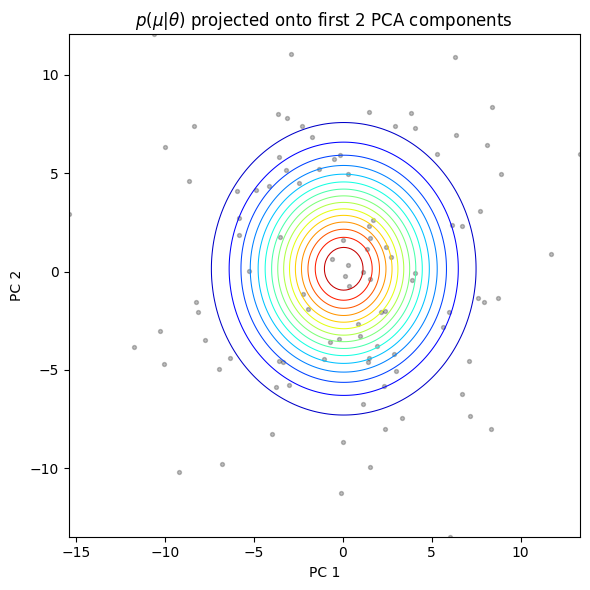

mean-parma1 =  -0.05254891188002018      mean-param2 =  10.808303416139415


<Figure size 500x400 with 0 Axes>

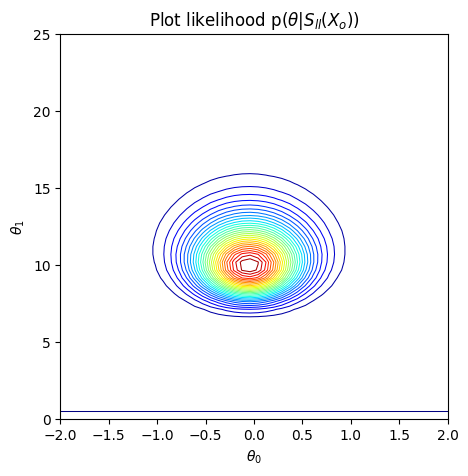

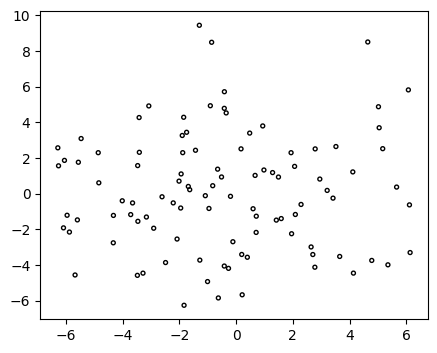

In [5]:
DIR = 'results/FFD' 
#IMG_FOLDER = "/home/amaranth2/Downloads/SimpleFace"
#IMG_FOLDER = os.path.join("/home/quinoa/LiFIMI_Attack","images_test")
IMG_FOLDER = os.path.join(PROJ_DIR,"images_test")
OUT_FOLDER = "/home/quinoa/out_folder"
problem = problem_FFD_image.FFD_Image_Problem(N=150, n=100)
problem.img_folder = IMG_FOLDER
problem.out_img_folder = OUT_FOLDER
problem.true_mean = 0.0
problem.true_var = 10.0
# Read the images for experiments
problem.get_work_imgs()

true_theta = problem.get_true_theta()
## FFD parameter scale
problem.ffd_scale = FFD_SCALE

## The simulator returns the observed mu params and 
## the deformed images
problem.data_obs, problem.imgs_obs = problem.simulator(true_theta)
## Compute PCA over the observed data
problem.compute_pca(n_components=15)
## Pick a mu param
#problem.y_obs, problem.imgs_obs = problem.statistics(data=problem.data_obs,images=problem.imgs_obs, theta=true_theta)
problem.y_obs, _ = problem.statistics(data=problem.data_obs,images=problem.imgs_obs, theta=true_theta)

## Sample thetas from the true posterior
true_samples = problem.sample_from_true_posterior()
## Get the true theta
theta_true = problem.get_true_theta()

## Visualize the likelihood of the samples p(x|theta)
problem.visualize()
plt.figure(figsize=(5,4))
visualization.plot_likelihood(samples=true_samples,
                              log_likelihood_function=problem.log_likelihood,
                              dimensions=(0,1),
                              bounded = False,
                              xmin = -2.0,
                              xmax = 2.0,
                              ymin = 0.0,
                              ymax = 25.0)
plt.show()
visualization.plot_samples(problem.data_obs)

### Visualize warped images

Plotting original images


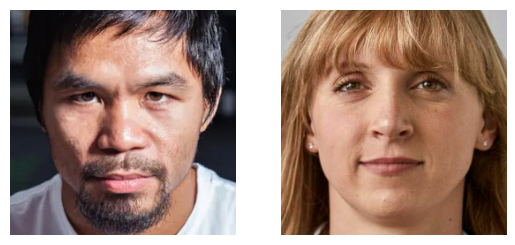

Plotting warped images


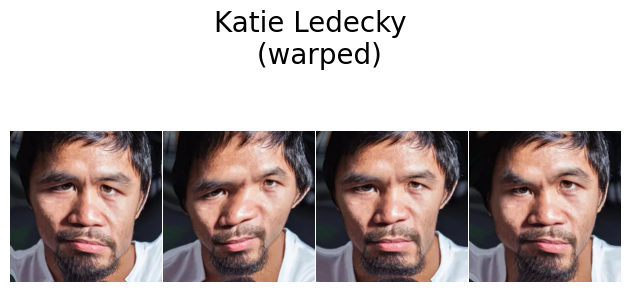

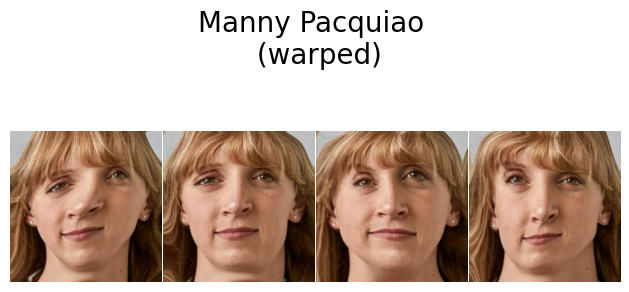

In [6]:
# Original images
print("Plotting original images")
figs,axes = plt.subplots(1,len(problem.work_imgs))
for k,img in enumerate(problem.work_imgs):
    axes[k].imshow(img[:,:,::-1])
    axes[k].set_axis_off()
plt.show()

print("Plotting warped images")
imgs = problem.imgs_obs
imgs_1 = imgs[0:4]
figs,axes = plt.subplots(1,4)
figs.suptitle('Katie Ledecky \n (warped)', fontsize=20, y=0.92)
#figs.tight_layout(rect=[0, 0, 1, 0.9])
for i in range(4):
    axes[i].imshow(imgs_1[i][:,:,::-1])
    axes[i].set_axis_off()
figs.tight_layout()
plt.subplots_adjust(top=0.99,wspace=0.01)
plt.show()

imgs_2 = imgs[imgs.shape[0]//2+1:imgs.shape[0]//2+5]
figs,axes = plt.subplots(1,4)
figs.suptitle('Manny Pacquiao \n (warped)', fontsize=20, y=0.92)
#plt.tight_layout()
for i in range(4):
    axes[i].imshow(imgs_2[i][:,:,::-1])
    axes[i].set_axis_off()
figs.tight_layout()
plt.subplots_adjust(top=0.99,wspace=0.01)
plt.show()

In [ ]:
## Sequential Neural Likelihood
hyperparams = ABC_algorithms.Hyperparams()
hyperparams.save_dir = DIR
hyperparams.device = 'cuda:0' if USE_CUDA else 'cpu'
hyperparams.num_sim = 200#1600#4000                   # number of sampling/simulation rounds
hyperparams.L = 10                                # number of learning rounds
hyperparams.type = 'cnnimg'
hyperparams.stat = 'infomax'                     # statistics function: infomax/moment/score  

#Hyperparameters for StatNet
hyperparams.n_neg = 5
hyperparams.bs = 32
hyperparams.lr = 8.0e-6

hyperparams.estimator = MI_ESTIMATOR                     # MI estimator; JSD (accurate) or DC (fast)

hyperparams.stat_max_iter = 400#1200   ### Number of maximum training iterations
## Hyperparams NDE
hyperparams.nde = NDE_NET                         # nde; MAF (D>1) or MDN (D=1)
hyperparams.nde_bs = 16
hyperparams.nde_lr = 1e-6
from lfi.utils import discrepancy, visualization

print('\n SNL ABC')
print(f"Imgs observed: {problem.imgs_obs.shape}")
problem.n = 2 # Number of image simulations (only one is chosen)
snl_abc = SNL2ABC.SNL2_ABC_Image(problem, discrepancy=discrepancy.eculidean_dist, hyperparams=hyperparams)
snl_abc.run()

JSD_array = []
for l in range(len(snl_abc.nde_array)):
    print('Iteration: ', l+1)
    snl_abc.nde_net = snl_abc.nde_array[l]
    Xs, Ys, Zs = visualization.plot_likelihood(samples=true_samples,
                                               log_likelihood_function=snl_abc.log_likelihood,
                                               dimensions=(0,1),
                                               bounded=False,
                                               return_data=True,
                                               xmin = -2.0,
                                               xmax = 2.0,
                                               ymin = 0.0,
                                               ymax = 25.0)
    np.save(f"Xs_iter{l}_{NDE_NET}_mi_{MI_ESTIMATOR}_scale_{FFD_SCALE}.npy", Xs)
    np.save(f"Ys_iter{l}_{NDE_NET}_mi_{MI_ESTIMATOR}_scale_{FFD_SCALE}.npy", Ys)
    np.save(f"Zs_iter{l}_{NDE_NET}_mi_{MI_ESTIMATOR}_scale_{FFD_SCALE}.npy", Zs)
    plt.show()
    JSD = discrepancy.JSD(problem.log_likelihood, snl_abc.log_likelihood, true_samples, true_samples, N_grid=30)
    JSD_array.append(JSD)
    print('JSD snl = ', JSD)
#uos.save_object(DIR, 'JSD_SNL', JSD_array)


 SNL ABC
Imgs observed: (200, 256, 256, 3)
iteration  0
[sampling] finished sampling  2
[sampling] finished sampling  4
[sampling] finished sampling  6
[sampling] finished sampling  8
[sampling] finished sampling  10
[sampling] finished sampling  12
[sampling] finished sampling  14
[sampling] finished sampling  16
[sampling] finished sampling  18

 > fitting encoder
learn stat, all_stats: torch.Size([20, 256, 256, 3])
summary statistic dim = 4 original dim = 72
architecture [72, 100, 100, 4]
Out front end: 100
Out front end: 100
Optimizer max_iter: 1200
finished: t= 0 loss= 0.0027222661301493645 loss val= 1.4062970876693726e-07 best loss 1.4062970876693726e-07
finished: t= 120 loss= 0.0011781882494688034 loss val= -3.9381906390190125e-05 best loss -6.025191396474838e-05
finished: t= 240 loss= -0.0019604815170168877 loss val= -1.8804334104061127e-05 best loss -6.110966205596924e-05
finished: t= 360 loss= -0.0006064213812351227 loss val= -8.968636393547058e-06 best loss -6.1109662055969

### Plot and compute SNL JSD (in case the previous cell fails)

In [ ]:
JSD_array = []
for l in range(len(snl_abc.nde_array)):
    print('Iteration: ', l+1)
    snl_abc.nde_net = snl_abc.nde_array[l]
    Xs, Ys, Zs = visualization.plot_likelihood(samples=true_samples,
                                               log_likelihood_function=snl_abc.log_likelihood,
                                               dimensions=(0,1),
                                               bounded=False,
                                               return_data=True,
                                               xmin = -2.0,
                                               xmax = 2.0,
                                               ymin = 0.0,
                                               ymax = 25.0)
    np.save(f"Xs_iter{l}.npy", Xs)
    np.save(f"Ys_iter{l}.npy", Ys)
    np.save(f"Zs_iter{l}.npy", Zs)
    plt.show()
    JSD = discrepancy.JSD(problem.log_likelihood, snl_abc.log_likelihood, true_samples, true_samples, N_grid=30)
    JSD_array.append(JSD)
    print('JSD snl = ', JSD)